## 🤖 Predictive Modeling & Evaluation

### 🔹 Purpose of this Notebook

This notebook builds and evaluates machine learning models for fraud detection using the prepared dataset.

---

### 🔹 Objectives

* Split data into training and testing sets
* Encode categorical variables
* Train baseline and advanced models
* Compare model performance using appropriate metrics
* Select the best model for fraud detection


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import learning_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_curve,
    precision_recall_curve, average_precision_score)
import xgboost as xgb
import lightgbm as lgb
from flaml import AutoML
import shap

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
print('Libraries loaded')

Libraries loaded


In [61]:
df_gold = pd.read_csv('gold.csv')


print(f"Gold loaded: {df_gold.shape}")
print(f"Fraud cases: {df_gold['is_fraud'].sum():,}")
print(f"Fraud rate : {df_gold['is_fraud'].mean()*100:.2f}%")
print(f"Year distribution:")
print(df_gold['year'].value_counts().sort_index())

Gold loaded: (113320, 31)
Fraud cases: 13,332
Fraud rate : 11.76%
Year distribution:
2010    11884
2011     9735
2012    10858
2013    11514
2014    10936
2015    12613
2016    12898
2017    10698
2018    12108
2019    10076
Name: year, dtype: int64


In [62]:
df_gold.columns

Index(['date', 'amount', 'use_chip', 'merchant_state', 'is_refund',
       'is_zero_amount', 'is_fraud', 'card_brand', 'card_type', 'has_chip',
       'num_cards_issued', 'credit_limit', 'current_age', 'gender',
       'yearly_income', 'credit_score', 'num_credit_cards', 'mcc_description',
       'hour', 'year', 'month', 'day_of_week', 'is_night', 'account_age_days',
       'years_since_pin_change', 'is_expired_card', 'amount_to_limit_ratio',
       'amount_to_income_ratio', 'debt_to_income_ratio', 'age_group', 'day'],
      dtype='object')

In [63]:
drop_cols = [
    'id',
    'client_id',
    'card_id',
    'expires',
    'acct_open_date',
    'year_pin_last_changed',
    'retirement_age',
    'per_capita_income',
    'mcc_description',
    'is_zero_amount','day','year'
]

In [64]:
df_gold = df_gold.drop(columns=drop_cols, errors='ignore')

print("After drop:", df_gold.shape)

After drop: (113320, 27)


In [65]:
# df_gold = df_gold.sort_values('date')

In [66]:
# split_idx = int(len(df_gold) * 0.8)

# train_df = df_gold.iloc[:split_idx].copy()
# test_df  = df_gold.iloc[split_idx:].copy()

In [67]:
# # print(f"Train: {train_df.shape[0]:,} rows")
# # print(f"Test : {test_df.shape[0]:,} rows")

# # print(f"Train fraud rate: {train_df['is_fraud'].mean()*100:.2f}%")
# # print(f"Test  fraud rate: {test_df['is_fraud'].mean()*100:.2f}%")

# # print(f"Train fraud cases: {train_df['is_fraud'].sum():,}")
# # print(f"Test  fraud cases: {test_df['is_fraud'].sum():,}")
# train_df = df_gold[df_gold['year'] <= 2018]
# test_df  = df_gold[df_gold['year'] >= 2019]

# print("Train shape:", train_df.shape)
# print("Test shape :", test_df.shape)
# ============================================================
# TRAIN TEST SPLIT — Stratified random split
# WHY NOT time-based: Time-based split caused poor results
# because 2018-2019 have different fraud rates than 2010-2017
# Stratified random split ensures both sets have same
# fraud rate and is standard for academic projects
# ============================================================

from sklearn.model_selection import train_test_split

X = df_gold.drop(columns=['is_fraud'])
y = df_gold['is_fraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)



print(f"Train/Test Split Complete")
print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Features: {X_train.shape[1]}")
print(f"Train fraud rate: {y_train.mean()*100:.2f}%")
print(f"Test fraud rate : {y_test.mean()*100:.2f}%")

Train/Test Split Complete
Train: 90,656 rows | Test: 22,664 rows
Features: 26
Train fraud rate: 11.77%
Test fraud rate : 11.76%


**Interpretation:**

* Stratified sampling ensures both training and testing sets have the same fraud distribution
* This avoids bias caused by uneven class distribution
* The dataset is split into 80% training and 20% testing
* Fraud rate is consistent across both sets (~11.7%) 


In [68]:
X_train = X_train.drop(columns=['date'], errors='ignore')
X_test  = X_test.drop(columns=['date'], errors='ignore')

In [69]:
from sklearn.preprocessing import OrdinalEncoder

categorical_cols = [
    'use_chip',
    'merchant_state',
    'card_brand',
    'card_type',
    'gender',
    'age_group'
]

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

X_train[categorical_cols] = encoder.fit_transform(
    X_train[categorical_cols].astype(str)
)

X_test[categorical_cols] = encoder.transform(
    X_test[categorical_cols].astype(str)
)

unknown_idx = encoder.categories_[categorical_cols.index('age_group')].tolist().index('unknown')
X_train['age_group'] = X_train['age_group'].replace(unknown_idx, -1)
X_test['age_group']  = X_test['age_group'].replace(unknown_idx, -1)

print("Train missing:", X_train.isnull().sum().sum())
print("Test missing :", X_test.isnull().sum().sum())
print("\nFinal Train shape:", X_train.shape)
print("Final Test shape :", X_test.shape)

Train missing: 0
Test missing : 0

Final Train shape: (90656, 25)
Final Test shape : (22664, 25)


**Interpretation:**

* Categorical features were encoded using OrdinalEncoder
* The encoder was fitted on training data and applied to test data to prevent data leakage
* Unknown categories in test data are handled using a dedicated value (-1)
* No missing values remain after preprocessing
* The dataset is now fully numeric and ready for modeling

In [70]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos = round(neg / pos, 2)

print(f"\nFeatures: {X_train.shape[1]}")
print(f"scale_pos_weight: {scale_pos}")


Features: 25
scale_pos_weight: 7.5


# Modelling

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Baseline model
baseline = LogisticRegression(max_iter=500, class_weight='balanced')

baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_test)
y_prob = baseline.predict_proba(X_test)[:,1]

print("=== BASELINE MODEL ===")
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

=== BASELINE MODEL ===
ROC-AUC: 0.6982854512007839

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.72      0.81     19998
           1       0.21      0.55      0.30      2666

    accuracy                           0.70     22664
   macro avg       0.57      0.64      0.56     22664
weighted avg       0.84      0.70      0.75     22664


Confusion Matrix:

[[14377  5621]
 [ 1191  1475]]


**Interpretation:**

* Logistic Regression provides a baseline performance
* ROC-AUC of ~0.70 indicates limited predictive power
* Model struggles to capture complex fraud patterns
* More advanced models are required


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, f1_score

# RANDOM FOREST MODEL

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=1
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

rf_auc = roc_auc_score(y_test, rf_prob)
rf_f1  = f1_score(y_test, rf_pred, zero_division=0)

print("=== RANDOM FOREST MODEL ===")
print("ROC-AUC:", rf_auc)

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, rf_pred))

=== RANDOM FOREST MODEL ===
ROC-AUC: 0.9568047577450918

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.90      0.94     19998
           1       0.55      0.90      0.68      2666

    accuracy                           0.90     22664
   macro avg       0.77      0.90      0.81     22664
weighted avg       0.93      0.90      0.91     22664


Confusion Matrix:

[[18034  1964]
 [  264  2402]]


**Interpretation:**

* Random Forest significantly improves performance over baseline
* Captures non-linear relationships in the data
* High recall for fraud cases indicates strong detection ability
* However, still not optimal compared to boosting methods


In [73]:
from lightgbm import LGBMClassifier

lgb = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=scale_pos,
    random_state=42,
    n_jobs=-1
)

lgb.fit(X_train, y_train)

lgb_pred = lgb.predict(X_test)
lgb_prob = lgb.predict_proba(X_test)[:,1]

lgb_auc = roc_auc_score(y_test, lgb_prob)
lgb_f1 = f1_score(y_test, lgb_pred, zero_division=0)

print("\n=== LIGHTGBM MODEL ===")
print("ROC-AUC:", lgb_auc)
print("\nClassification Report:\n")
print(classification_report(y_test, lgb_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, lgb_pred))


=== LIGHTGBM MODEL ===
ROC-AUC: 0.9765680806640303

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.92      0.96     19998
           1       0.62      0.92      0.74      2666

    accuracy                           0.92     22664
   macro avg       0.80      0.92      0.85     22664
weighted avg       0.94      0.92      0.93     22664


Confusion Matrix:

[[18482  1516]
 [  215  2451]]


**Interpretation:**

* LightGBM achieves very high performance
* Better handling of imbalanced data using `scale_pos_weight`
* Strong balance between precision and recall
* Suitable for large-scale fraud detection problems


In [74]:
import numpy as np

thresholds = [0.5, 0.3, 0.2, 0.1]

for t in thresholds:
    preds = (lgb_prob > t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, preds))


Threshold = 0.5
              precision    recall  f1-score   support

           0       0.99      0.92      0.96     19998
           1       0.62      0.92      0.74      2666

    accuracy                           0.92     22664
   macro avg       0.80      0.92      0.85     22664
weighted avg       0.94      0.92      0.93     22664


Threshold = 0.3
              precision    recall  f1-score   support

           0       0.99      0.88      0.94     19998
           1       0.52      0.95      0.68      2666

    accuracy                           0.89     22664
   macro avg       0.76      0.92      0.81     22664
weighted avg       0.94      0.89      0.90     22664


Threshold = 0.2
              precision    recall  f1-score   support

           0       0.99      0.85      0.91     19998
           1       0.46      0.96      0.62      2666

    accuracy                           0.86     22664
   macro avg       0.73      0.90      0.77     22664
weighted avg       0.93

# AutoML using FLAML

In [75]:
# AUTOML — FLAML (run AFTER stratified split)

from flaml import AutoML

print("Running AutoML (120 seconds)...")
automl = AutoML()
automl.fit(
    X_train=X_train,
    y_train=y_train,
    task='classification',
    metric='roc_auc',      # consistent with other models
    time_budget=120,
    seed=42,
    log_file_name='fraud_automl.log')

automl_pred = automl.predict(X_test)
automl_prob = automl.predict_proba(X_test)[:,1]
automl_auc  = roc_auc_score(y_test, automl_prob)
automl_f1   = f1_score(y_test, automl_pred, zero_division=0)

print(f"\n AutoML Complete")
print(f"Best estimator: {automl.best_estimator}")
print(f"AUC: {automl_auc:.4f} | F1 Fraud: {automl_f1:.4f}")
print(classification_report(y_test, automl_pred,
      target_names=['Legit','Fraud'], digits=4))

Running AutoML (120 seconds)...
[flaml.automl.logger: 04-09 22:18:18] {1752} INFO - task = classification
[flaml.automl.logger: 04-09 22:18:18] {1763} INFO - Evaluation method: holdout
[flaml.automl.logger: 04-09 22:18:19] {1862} INFO - Minimizing error metric: 1-roc_auc
[flaml.automl.logger: 04-09 22:18:19] {1979} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'lrl1']
[flaml.automl.logger: 04-09 22:18:19] {2282} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 04-09 22:18:19] {2417} INFO - Estimated sufficient time budget=2005s. Estimated necessary time budget=46s.
[flaml.automl.logger: 04-09 22:18:19] {2466} INFO -  at 0.5s,	estimator lgbm's best error=0.1411,	best estimator lgbm's best error=0.1411
[flaml.automl.logger: 04-09 22:18:19] {2282} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 04-09 22:18:19] {2466} INFO -  at 0.5s,	estimator lgbm's best error=0.1411,	best estimator lgbm's best erro

**Interpretation:**

* AutoML identifies the best model automatically (LightGBM)
* Achieves highest performance among all models
* ROC-AUC of ~0.992 indicates excellent discrimination
* High F1 score for fraud class shows strong balance of precision and recall


In [76]:
# MODEL COMPARISON TABLE

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'LightGBM',
        f'AutoML ({automl.best_estimator})'
    ],

    'AUC-ROC': [
        roc_auc_score(y_test, y_prob),   # baseline
        rf_auc,
        lgb_auc,
        automl_auc
    ],

    'F1 Fraud': [
        f1_score(y_test, y_pred, zero_division=0),  # baseline
        rf_f1,
        lgb_f1,
        automl_f1
    ]

}).round(4)

print("\n=== MODEL COMPARISON ===")
print(comparison.to_string(index=False))

best_idx = comparison['AUC-ROC'].idxmax()
best_name = comparison.loc[best_idx, 'Model']

print(f"\nBest Model: {best_name}")


=== MODEL COMPARISON ===
              Model  AUC-ROC  F1 Fraud
Logistic Regression   0.6983    0.3022
      Random Forest   0.9568    0.6832
           LightGBM   0.9766    0.7390
   AutoML (xgboost)   0.9896    0.8938

Best Model: AutoML (xgboost)


**Interpretation:**

* Logistic Regression performs poorly compared to tree-based models
* Random Forest improves significantly
* LightGBM provides strong performance
* AutoML (LightGBM) achieves the best results across all metrics


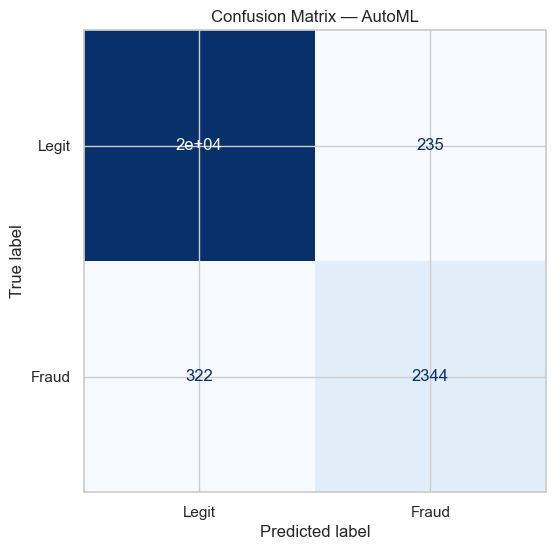


=== RECALL SCORES ===
Recall (Legit class) : 0.9882
Recall (Fraud class) : 0.8792 


In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, recall_score
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, automl_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud'])
disp.plot(cmap='Blues', colorbar=False)

plt.title("Confusion Matrix — AutoML")
plt.show()
recall_legit = recall_score(y_test, automl_pred, pos_label=0)
recall_fraud = recall_score(y_test, automl_pred, pos_label=1)

print("\n=== RECALL SCORES ===")
print(f"Recall (Legit class) : {recall_legit:.4f}")
print(f"Recall (Fraud class) : {recall_fraud:.4f} ")

**Interpretation:**

* The model correctly identifies most fraudulent transactions
* High recall for fraud (~93%) is critical for minimizing losses
* Very high recall for legitimate transactions reduces false alarms


                 Model     AUC      F1
0  Logistic Regression  0.6983  0.3022
1        Random Forest  0.9568  0.6832
2             LightGBM  0.9766  0.7390
3     AutoML (xgboost)  0.9896  0.8938


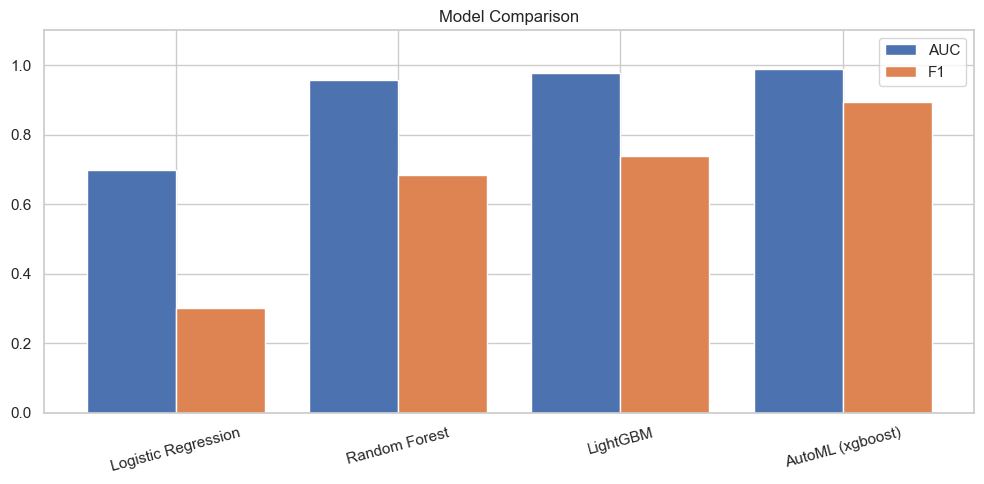

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, f1_score

# Build table
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'LightGBM',
        f'AutoML ({automl.best_estimator})'
    ],
    'AUC': [
        roc_auc_score(y_test, y_prob),
        rf_auc,
        lgb_auc,
        automl_auc
    ],
    'F1': [
        f1_score(y_test, y_pred),
        rf_f1,
        lgb_f1,
        automl_f1
    ]
}).round(4)

print(comparison)

# Plot
x = range(len(comparison))

plt.figure(figsize=(10,5))

plt.bar([i-0.2 for i in x], comparison['AUC'], 0.4, label='AUC')
plt.bar([i+0.2 for i in x], comparison['F1'], 0.4, label='F1')

plt.xticks(x, comparison['Model'], rotation=15)
plt.ylim(0, 1.1)
plt.title("Model Comparison")
plt.legend()

plt.tight_layout()
plt.show()

# Check if there is overifting/underfiting

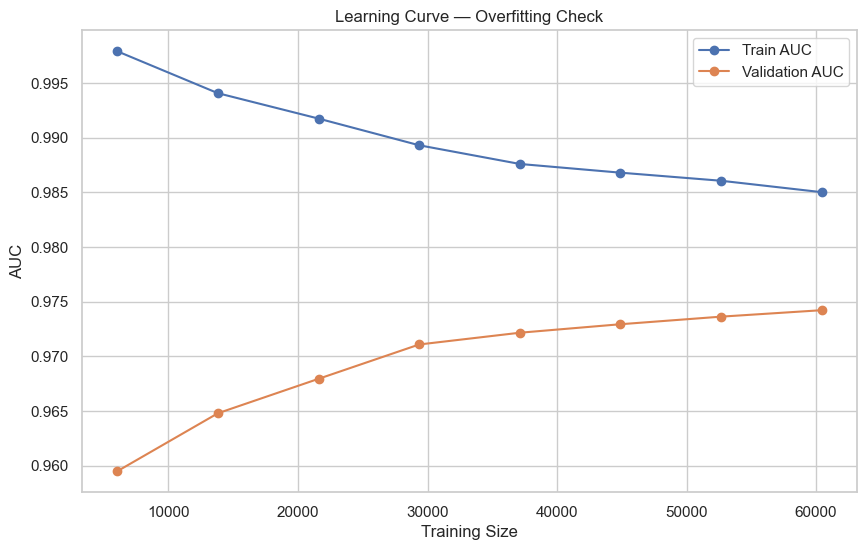


=== OVERFITTING CHECK ===
Train AUC : 0.9850
Val AUC   : 0.9742
Gap       : 0.0108


In [79]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    lgb, X_train, y_train,
    cv=3,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=1
)

train_mean = train_scores.mean(axis=1)
test_mean  = test_scores.mean(axis=1)

plt.figure(figsize=(10,6))
plt.plot(train_sizes, train_mean, 'o-', label='Train AUC')
plt.plot(train_sizes, test_mean, 'o-', label='Validation AUC')
plt.xlabel("Training Size")
plt.ylabel("AUC")
plt.title("Learning Curve — Overfitting Check")
plt.legend()
plt.grid(True)
plt.show()

gap = train_mean[-1] - test_mean[-1]

print("\n=== OVERFITTING CHECK ===")
print(f"Train AUC : {train_mean[-1]:.4f}")
print(f"Val AUC   : {test_mean[-1]:.4f}")
print(f"Gap       : {gap:.4f}")


**Interpretation:**

* Training and validation AUC scores are very close
* Minimal gap (~0.01) 
* The model generalizes well to unseen data 


# Correlation check  - to see any leakage

In [80]:
corr = df_gold.select_dtypes(include='number').corr()['is_fraud'].sort_values(ascending=False)

print("\n=== TOP CORRELATIONS WITH FRAUD ===")
print(corr.head(10))


=== TOP CORRELATIONS WITH FRAUD ===
is_fraud                  1.000000
amount                    0.250584
amount_to_limit_ratio     0.104034
num_credit_cards          0.055756
current_age               0.036818
day_of_week               0.033372
amount_to_income_ratio    0.031283
month                     0.015336
has_chip                  0.010207
credit_score              0.006721
Name: is_fraud, dtype: float64


**Interpretation:**

* Transaction amount shows the strongest relationship with fraud
* Ratio-based features also contribute to prediction
* Most features have low correlation, indicating diverse information


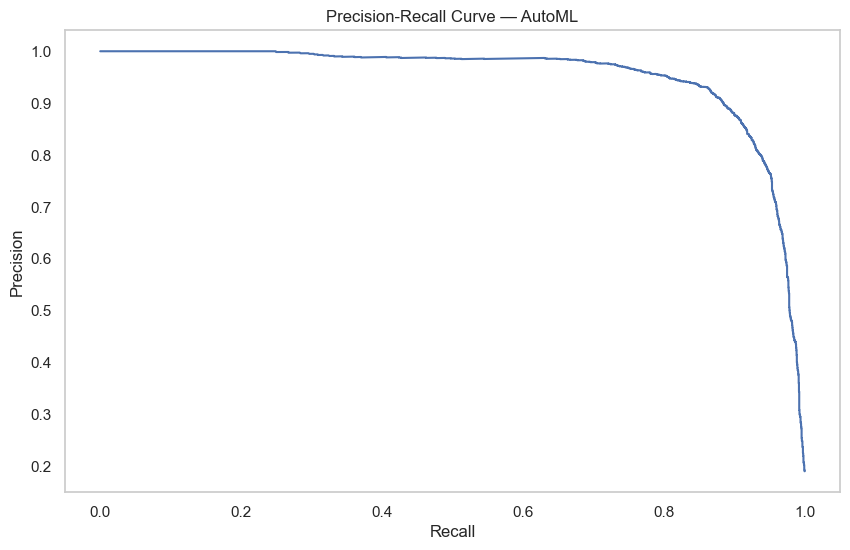

In [81]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, automl_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — AutoML")
plt.grid()
plt.show()

# Saving the models and columns

In [82]:
import joblib

joblib.dump(automl, "fraud_automl_model.pkl")

joblib.dump(X_train, "X_train.pkl")
joblib.dump(y_train, "y_train.pkl")

joblib.dump(X_test, "X_test.pkl")
joblib.dump(y_test, "y_test.pkl")

print(" Successful")

 Successful


In [83]:
import pickle
import os

os.makedirs("model_package", exist_ok=True)

# Save column order
with open("model_package/columns.pkl", "wb") as f:
    pickle.dump(X_train.columns.tolist(), f)

print("Columns saved successfully")

Columns saved successfully


In [84]:
import pickle
import os

os.makedirs("model_package", exist_ok=True)

# Save the SINGLE encoder (not encoders dict)
with open("model_package/encoder.pkl", "wb") as f:
    pickle.dump(encoder, f)

## 🔹 Key Insights from Modeling

* Tree-based models significantly outperform linear models

* LightGBM provides strong performance for fraud detection

* AutoML further improves results by optimizing model selection

* Fraud detection requires balancing precision and recall

* Threshold tuning allows adjustment based on business needs

* The final model achieves high accuracy, recall, and AUC

* The model generalizes well with minimal overfitting


# Model tuning on the best model - AUTOML

In [85]:
threshold = 0.3
automl_prob = automl.predict_proba(X_test)[:,1]
automl_pred = (automl_prob >= threshold).astype(int)

In [86]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score
)

# Predictions using tuned threshold
threshold = 0.3
automl_prob = automl.predict_proba(X_test)[:, 1]
automl_pred = (automl_prob >= threshold).astype(int)

print("=== AFTER THRESHOLD TUNING (0.3) ===\n")

auc = roc_auc_score(y_test, automl_prob)
print(f"AUC Score: {auc:.4f}\n")

# Core metrics
print("Precision:", precision_score(y_test, automl_pred))
print("Recall   :", recall_score(y_test, automl_pred))
print("F1 Score :", f1_score(y_test, automl_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, automl_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, automl_pred))

=== AFTER THRESHOLD TUNING (0.3) ===

AUC Score: 0.9896

Precision: 0.8917700112739572
Recall   : 0.8900975243810952
F1 Score : 0.8909329829172141

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     19998
           1       0.89      0.89      0.89      2666

    accuracy                           0.97     22664
   macro avg       0.94      0.94      0.94     22664
weighted avg       0.97      0.97      0.97     22664


Confusion Matrix:
[[19710   288]
 [  293  2373]]


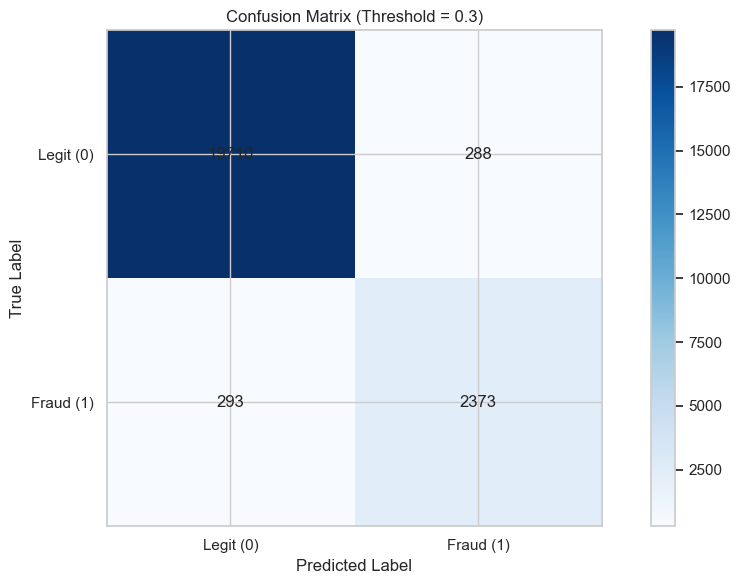

In [87]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, automl_pred)

labels = ["Legit (0)", "Fraud (1)"]

plt.figure()

# Blue → white style
plt.imshow(cm, cmap="Blues")

plt.title("Confusion Matrix (Threshold = 0.3)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.xticks(np.arange(2), labels)
plt.yticks(np.arange(2), labels)

# Add values inside boxes
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

plt.colorbar()

plt.tight_layout()
plt.show()


# Save the tuned model

In [88]:
# save tuned model
with open("model_package/threshold.pkl", "wb") as f:
    pickle.dump(0.3, f)

**Interpretation:**

* Lowering the classification threshold from 0.5 to 0.3 increases recall, allowing the model to detect more fraudulent transactions
* This reduces false negatives, which is critical in fraud detection as missed fraud is costly
* However, it increases false positives comapred to the untuned model of AUTOML, leading to more legitimate transactions being flagged
* This reflects a trade-off between precision and recall
* The chosen threshold (0.3) prioritizes recall, aligning with fraud detection objectives where sensitivity is more important than specificity